c:\Users\ga84cib\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\ga84cib\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'Raw Milk Prices'!$A:$AE.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
C:\Users\ga84cib\AppData\Local\Temp/ipykernel_16648/3599809199.py:48: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  series = series.resample("Q").last()
C:\Users\ga84cib\AppData\Local\Temp/ipykernel_16648/3599809199.py:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = series.resample("M").last()
C:\Users\ga84cib\AppData\Local\Temp/ipykernel_16648/3599809199.py:71: Fut

Italy (Real Prices, 2005–2024):
{'theta': 0.16037595690026799, 'mu': 26.099004640856627, 'sigma_long': 2.3586597624393333, 'cv': 0.09037355235942503, 'model': <statsmodels.tsa.ar_model.AutoRegResultsWrapper object at 0x000001F1239F9FF0>}
Italy coefficient of variation: 0.09177307402132238

Netherlands (Real Prices, 2005–2024):
{'theta': 0.06798280882547635, 'mu': 26.54456809357828, 'sigma_long': 3.9601234491958652, 'cv': 0.1491877146102033, 'model': <statsmodels.tsa.ar_model.AutoRegResultsWrapper object at 0x000001F11FFD6B00>}
Netherlands coefficient of variation: 0.15234455088199844

Italy (Nominal Prices, 2005–2024):
{'theta': 0.013429853223482908, 'mu': 61.76059097312686, 'sigma_long': 12.744073606529568, 'cv': 0.2063463675740205, 'model': <statsmodels.tsa.ar_model.AutoRegResultsWrapper object at 0x000001F1205C04C0>}

Netherlands (Nominal Prices, 2005–2024):
{'theta': 0.01866040005247735, 'mu': 44.49760007056698, 'sigma_long': 10.049907358087012, 'cv': 0.22585279525523314, 'model': 

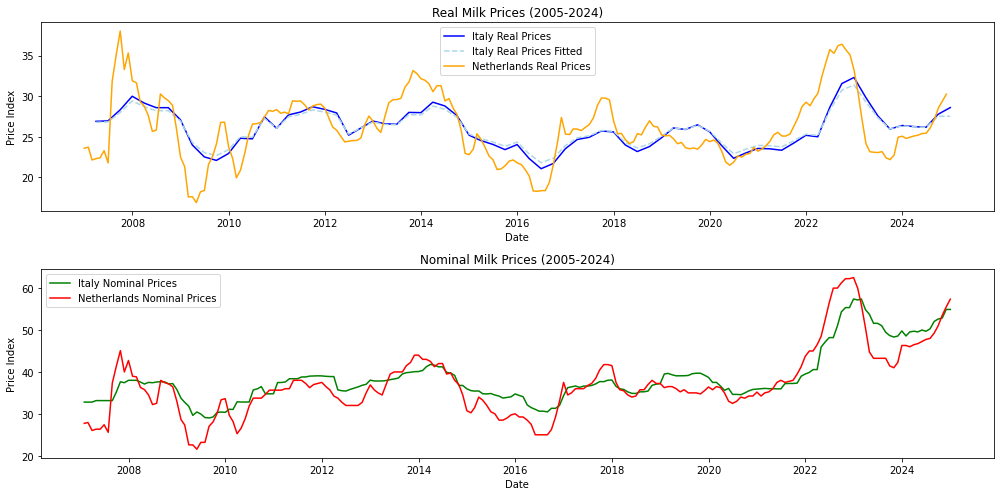

In [59]:

import pandas as pd
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt

# === Load HICP data from Eurostat Excel ===
hicp_excel_path = "figures/prc_hicp_midx__custom_17532692_spreadsheet.xlsx"
hicp_xls = pd.ExcelFile(hicp_excel_path)

# Read correct sheet and header
df_hicp_food = pd.read_excel(hicp_xls, sheet_name="Sheet 13", header=8)

# Extract time series for Italy and Netherlands
it_row = df_hicp_food[df_hicp_food["TIME"] == "Italy"]
nl_row = df_hicp_food[df_hicp_food["TIME"] == "Netherlands"]

hicp_it = it_row.drop(columns="TIME").T.squeeze()
hicp_nl = nl_row.drop(columns="TIME").T.squeeze()

# Convert indices to datetime and values to numeric
hicp_it.index = pd.to_datetime(hicp_it.index, format="%Y-%m")
hicp_nl.index = pd.to_datetime(hicp_nl.index, format="%Y-%m")
hicp_it = pd.to_numeric(hicp_it, errors="coerce")
hicp_nl = pd.to_numeric(hicp_nl, errors="coerce")

# === Load Milk Price Excel ===
milk_path = "figures/eu-milk-historical-price-series_en.xlsx"
milk_xls = pd.ExcelFile(milk_path)

# Italy = column 12, Netherlands = column 19
milk_df = pd.read_excel(milk_xls, sheet_name="Raw Milk Prices", skiprows=6,
                        usecols=[0, 12, 19], names=["Date", "Italy", "Netherlands"], nrows=1000)
milk_df.dropna(inplace=True)
milk_df["Date"] = pd.to_datetime(milk_df["Date"], format="%Ym%m")
milk_df.set_index("Date", inplace=True)

milk_df["Italy"] = pd.to_numeric(milk_df["Italy"], errors="coerce")
milk_df["Netherlands"] = pd.to_numeric(milk_df["Netherlands"], errors="coerce")

# === Restrict and deflate ===
milk_df = milk_df.loc["2007-01":"2024-12"]
it_real = milk_df["Italy"] / hicp_it.loc[milk_df.index] * 100
nl_real = milk_df["Netherlands"] / hicp_nl.loc[milk_df.index] * 100

# === AR(1) Modeling Function ===
def fit_ar1(series, freq="Q"):
    if freq == "Q":
        series = series.resample("Q").last()
    if freq == "2Q":
        series = series.resample("2Q").last()
    if freq == "M":
        series = series.resample("M").last()
    if freq == "4M":
        series = series.resample("4M").last()
    model = AutoReg(series, lags=1, old_names=False).fit()
    alpha, phi = model.params
    mu = alpha / (1 - phi)
    theta = -np.log(phi)
    sigma = np.std(model.resid, ddof=1)
    sigma_long = sigma / np.sqrt(1 - (1 - theta)**2)
    cv = sigma_long / mu
    return {"theta": theta, "mu": mu, "sigma_long": sigma_long, "cv": cv, "model": model}

# === Run analysis ===
it_result = fit_ar1(it_real, freq="Q")
nl_result = fit_ar1(nl_real, freq="M")

# === Display results ===
print("Italy (Real Prices, 2005–2024):")
print(it_result)
print("Italy coefficient of variation:", np.std(it_real.resample("Q").last(), ddof=1)/np.mean(it_real.resample("Q").last()))    
print("\nNetherlands (Real Prices, 2005–2024):")
print(nl_result)
print("Netherlands coefficient of variation:", np.std(nl_real.resample("M").last(), ddof=1)/np.mean(nl_real.resample("M").last()))

# === Run analysis for nominal prices ===
it_nominal = milk_df["Italy"].resample("M").last()
nl_nominal = milk_df["Netherlands"].resample("M").last()
it_nominal_result = fit_ar1(it_nominal, freq="Q")
nl_nominal_result = fit_ar1(nl_nominal, freq="M")

# === Display nominal results ===
print("\nItaly (Nominal Prices, 2005–2024):")
print(it_nominal_result)
print("\nNetherlands (Nominal Prices, 2005–2024):")
print(nl_nominal_result)


def plot_results(it_real, nl_real, it_nominal, nl_nominal):
    plt.figure(figsize=(14, 7))
    
    plt.subplot(2, 1, 1)
    quarterly_it_real = it_real.resample("Q").last()
    quarterly_nl_real = nl_real.resample("Q").last()
    fitted_it = it_result["model"].fittedvalues
    #add one dummy value to the end of fitted_it to match the length of quarterly_it_real
    #how can I add a value to a pandas Series?
    fitted_it = pd.Series(np.append(fitted_it, fitted_it.iloc[-1]), index=quarterly_it_real.index)

    plt.plot(quarterly_it_real.index, quarterly_it_real, label='Italy Real Prices', color='blue')
    plt.plot(fitted_it, label='Italy Real Prices Fitted', linestyle='--', color='lightblue')
    plt.plot(nl_real.index, nl_real, label='Netherlands Real Prices', color='orange')
    plt.title('Real Milk Prices (2005-2024)')
    plt.xlabel('Date')
    plt.ylabel('Price Index')
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(it_nominal.index, it_nominal, label='Italy Nominal Prices', color='green')
    plt.plot(nl_nominal.index, nl_nominal, label='Netherlands Nominal Prices', color='red')
    plt.title('Nominal Milk Prices (2005-2024)')
    plt.xlabel('Date')
    plt.ylabel('Price Index')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_results(it_real, nl_real, it_nominal, nl_nominal)